# Problem Statement 1

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Generate time spent data
x = np.linspace(10, 110, 25)

# True decision boundary around 35–40
y = np.array([0 if val < 35 else 1 for val in x])

# Introduce noise (flip 3 labels)
noise_indices = np.random.choice(len(y), 3, replace=False)
y[noise_indices] = 1 - y[noise_indices]

# Save to CSV
data = pd.DataFrame({"Time_Spent": x, "Premium": y})
data.to_csv("premium_data.csv", index=False)

print(data.head())

   Time_Spent  Premium
0   10.000000        1
1   14.166667        0
2   18.333333        0
3   22.500000        0
4   26.666667        0


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [3]:
def hypothesis(x, w, b):
    z = w * x + b
    return sigmoid(z)

In [4]:
def cost_function(x, y, w, b):
    m = len(x)
    h = hypothesis(x, w, b)
    
    # To avoid log(0)
    epsilon = 1e-9
    cost = -(1/m) * np.sum(
        y * np.log(h + epsilon) +
        (1 - y) * np.log(1 - h + epsilon)
    )
    
    return cost

In [5]:
def gradient_descent(x, y, w, b, alpha):
    m = len(x)
    h = hypothesis(x, w, b)
    
    dw = (1/m) * np.sum((h - y) * x)
    db = (1/m) * np.sum(h - y)
    
    w = w - alpha * dw
    b = b - alpha * db
    
    return w, b

In [6]:
def logistic_regression(x, y, alpha=0.001, iterations=10000):
    
    w = 0
    b = 0
    
    for i in range(iterations):
        w, b = gradient_descent(x, y, w, b, alpha)
        
        if i % 1000 == 0:
            print(f"Iteration {i}, Cost: {cost_function(x, y, w, b)}")
    
    return w, b

In [7]:
# Load data
x = data["Time_Spent"].values
y = data["Premium"].values

w, b = logistic_regression(x, y)

print("Final Parameters:")
print("w =", w)
print("b =", b)

Iteration 0, Cost: 0.4797514190996722
Iteration 1000, Cost: 0.4716785635061414
Iteration 2000, Cost: 0.46748465078999807
Iteration 3000, Cost: 0.46359957219807724
Iteration 4000, Cost: 0.46000074441917144
Iteration 5000, Cost: 0.45666700279743033
Iteration 6000, Cost: 0.45357857115417666
Iteration 7000, Cost: 0.450717018242488
Iteration 8000, Cost: 0.44806520435004343
Iteration 9000, Cost: 0.4456072210359102
Final Parameters:
w = 0.033602379363783866
b = -0.5695523318117299


In [8]:
def predict(x, w, b):
    probs = hypothesis(x, w, b)
    return [1 if p >= 0.5 else 0 for p in probs]

In [9]:
y_pred = predict(x, w, b)
accuracy = np.mean(y_pred == y)
print("Accuracy:", accuracy)

Accuracy: 0.72


# Problem statement 2

In [10]:
class Customer:
    def __init__(self, monthly_income, total_spend, churn):
        self.monthly_income = monthly_income
        self.total_spend = total_spend
        self.churn = churn   # 0 or 1

In [11]:
dataset = [
    Customer(50000, 48000, 0),
    Customer(70000, 70000, 0),
    Customer(30000, 29000, 1),
    Customer(60000, 51000, 0),
    Customer(55000, 54000, 1),
    Customer(75000, 65000, 0),
    Customer(40000, 37000, 1),
    Customer(62000, 61000, 0),
    Customer(48000, 38000, 0),
    Customer(56000, 49500, 1)
]

In [12]:
new_point1 = Customer(51000, 45000, None)
new_point2 = Customer(51000, 50000, None)

In [13]:
import math

def euclidean_distance(p1, p2):
    return math.sqrt(
        (p1.monthly_income - p2.monthly_income)**2 +
        (p1.total_spend - p2.total_spend)**2
    )

In [14]:
def manhattan_distance(p1, p2):
    return abs(p1.monthly_income - p2.monthly_income) + \
           abs(p1.total_spend - p2.total_spend)

In [15]:
def knn_classify(dataset, new_point, k, distance_func):
    
    distances = []
    
    # Step A: Compute distances
    for data in dataset:
        dist = distance_func(new_point, data)
        distances.append((dist, data.churn))
    
    # Step B: Sort by distance
    distances.sort(key=lambda x: x[0])
    
    # Step C: Take first K
    k_nearest = distances[:k]
    
    # Step D: Count class labels
    count_0 = 0
    count_1 = 0
    
    for _, label in k_nearest:
        if label == 0:
            count_0 += 1
        else:
            count_1 += 1
    
    # Step E: Majority vote
    if count_1 > count_0:
        return 1
    else:
        return 0

In [16]:
print("Euclidean K=3")

print("Point (51000,45000):",
      knn_classify(dataset, new_point1, 3, euclidean_distance))

print("Point (51000,50000):",
      knn_classify(dataset, new_point2, 3, euclidean_distance))

Euclidean K=3
Point (51000,45000): 0
Point (51000,50000): 1


In [17]:
print("Manhattan K=3")

print("Point (51000,45000):",
      knn_classify(dataset, new_point1, 3, manhattan_distance))

print("Point (51000,50000):",
      knn_classify(dataset, new_point2, 3, manhattan_distance))

Manhattan K=3
Point (51000,45000): 0
Point (51000,50000): 1


In [18]:
for k in [3, 5]:
    print(f"\nK = {k}")
    print("Point1 Euclidean:",
          knn_classify(dataset, new_point1, k, euclidean_distance))
    print("Point2 Euclidean:",
          knn_classify(dataset, new_point2, k, euclidean_distance))


K = 3
Point1 Euclidean: 0
Point2 Euclidean: 1

K = 5
Point1 Euclidean: 0
Point2 Euclidean: 0


/var/folders/95/0629sd1158v7_7vls7s1txc40000gn/T/ipykernel_3949/2883575824.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


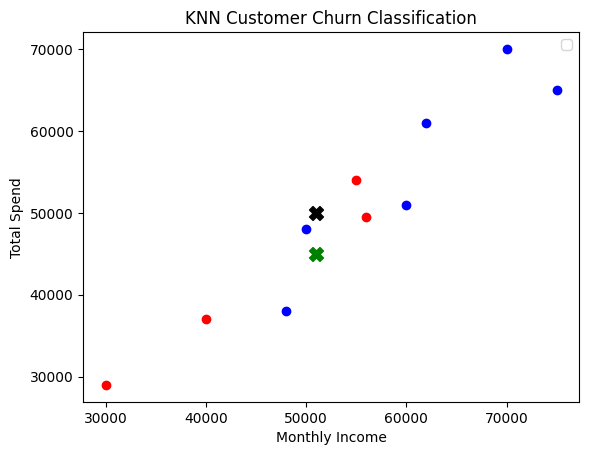

In [20]:
import matplotlib.pyplot as plt

for data in dataset:
    if data.churn == 0:
        plt.scatter(data.monthly_income, data.total_spend, color='blue')
    else:
        plt.scatter(data.monthly_income, data.total_spend, color='red')

# Plot new points
plt.scatter(51000, 45000, color='green', marker='X', s=100)
plt.scatter(51000, 50000, color='black', marker='X', s=100)

plt.xlabel("Monthly Income")
plt.ylabel("Total Spend")
plt.title("KNN Customer Churn Classification")
plt.legend()
plt.show()

# Problem Statement 3

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [22]:
df = pd.read_csv("gene_expression.csv")  # replace with your dataset

print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

Shape: (3000, 3)

First 5 rows:
    Gene One  Gene Two  Cancer Present
0       4.3       3.9               1
1       2.5       6.3               0
2       5.7       3.9               1
3       6.1       6.2               0
4       7.4       3.4               1

Missing values:
 Gene One          0
Gene Two          0
Cancer Present    0
dtype: int64


In [23]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [26]:
k_values = [1, 3, 5, 7, 9]
accuracy_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)
    
    print(f"K = {k}, Accuracy = {acc:.4f}")

K = 1, Accuracy = 0.9000
K = 3, Accuracy = 0.9250
K = 5, Accuracy = 0.9183
K = 7, Accuracy = 0.9250
K = 9, Accuracy = 0.9350


In [27]:
best_k = k_values[np.argmax(accuracy_list)]
print("Best K:", best_k)

Best K: 9


In [28]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.935


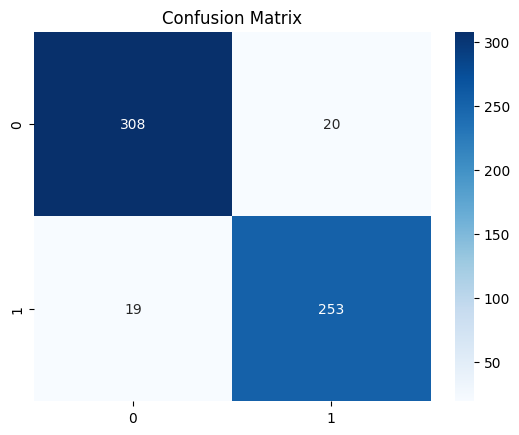

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       328
           1       0.93      0.93      0.93       272

    accuracy                           0.94       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.94      0.94      0.94       600



In [29]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

In [30]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_pca, y_train_pca)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


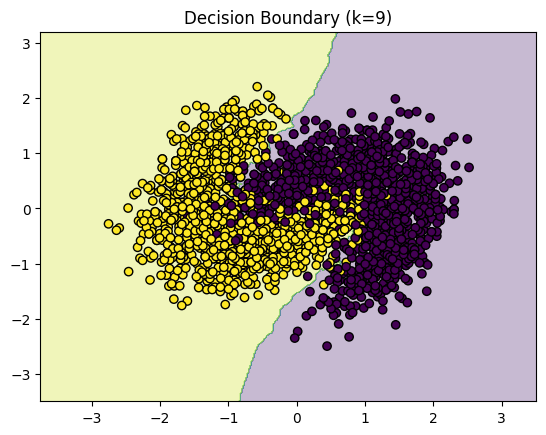

In [31]:
def plot_decision_boundary(model, X, y, k):
    h = 0.02
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.title(f"Decision Boundary (k={k})")
    plt.show()

plot_decision_boundary(knn_2d, X_train_pca, y_train_pca, best_k)

In [32]:
knn_euclidean = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_euclidean.fit(X_train, y_train)
y_pred_e = knn_euclidean.predict(X_test)

print("Euclidean Accuracy:", accuracy_score(y_test, y_pred_e))

Euclidean Accuracy: 0.935


In [33]:
knn_manhattan = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
y_pred_m = knn_manhattan.predict(X_test)

print("Manhattan Accuracy:", accuracy_score(y_test, y_pred_m))

Manhattan Accuracy: 0.9266666666666666


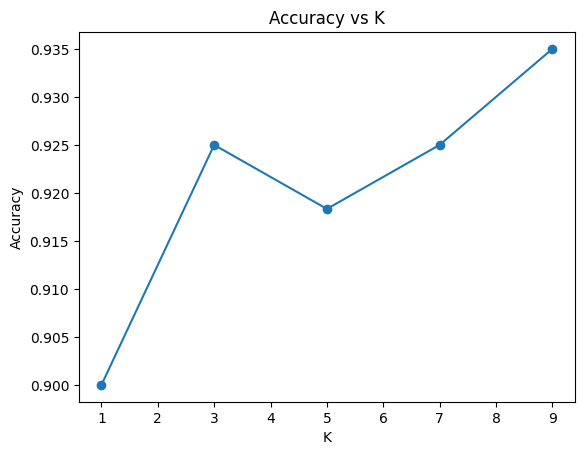

In [34]:
plt.plot(k_values, accuracy_list, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()